<a href="https://colab.research.google.com/github/ANQI-70/Capstone-Project/blob/main/Capstone_project_2_Mri_and_Alzheimers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#basic libraries

import numpy as np
import pandas as pd
import os

#visualization libraries

import missingno as msno
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jboysen/mri-and-alzheimers")

print("Path to dataset files:", path)

100%|██████████| 12.6k/12.6k [00:00<00:00, 6.76MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jboysen/mri-and-alzheimers/versions/1


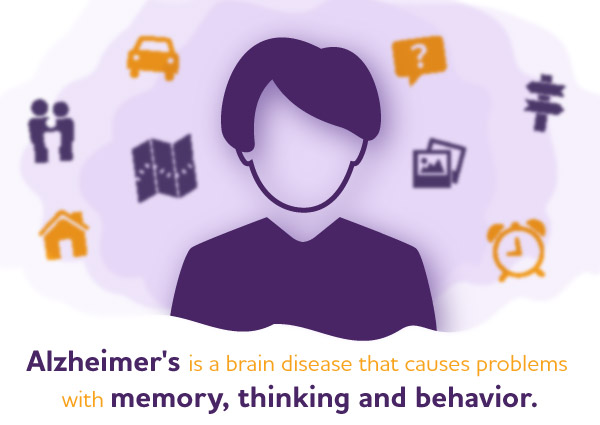

## Understand the dataset

### Understanding Alzheimer's and dementia
Alzheimer's is a type of dementia that affects memory, thinking, and behavior. Symptoms eventually grow severe enough to interfere with daily tasks.

Alzheimer's is the most common cause of dementia, a general term for memory loss and other cognitive abilities serious enough to interfere with daily life. Alzheimer's disease accounts for 60-80% of dementia cases.

Alzheimer's is not a normal part of aging. The greatest known risk factor is increasing age, and the majority of people with Alzheimer's are 65 and older. Alzheimer’s disease is considered to be younger-onset Alzheimer’s if it affects a person under 65. Younger-onset can also be referred to as early-onset Alzheimer’s. People with younger-onset Alzheimer’s can be in the early, middle or late stage of the disease.

Reference from [Alzheimer's association website](https://www.alz.org/alzheimers-dementia/what-is-alzheimers)

### Understand the research
Longitudinal MRI Data in Nondemented and Demented Older Adults:
This set consists of a longitudinal collection of 150 subjects aged 60 to 96. Each subject was scanned on two or more visits, separated by at least one year for a total of 373 imaging sessions.
For each subject, 3 or 4 individual T1-weighted MRI scans obtained in single scan sessions are included.
The subjects are all right-handed and include both men and women.
72 of the subjects were characterized as nondemented throughout the study.
64 of the included subjects were characterized as demented at the time of their initial visits and remained so for subsequent scans, including 51 individuals with mild to moderate Alzheimer’s disease.
Another 14 subjects were characterized as nondemented at the time of their initial visit and were subsequently characterized as demented at a later visit.

## Columns



**Subject ID**

**MRI ID**: One subject can have 3-4 MRI ID. (T1-weighted MRI scans: Use a shorter amount of time between the application of RF pulse and the measurement of signal. Highlight differences in tissue density and water content. Most often utilized to image the anatomy of the brain, spinal cord, bones, and joints.)

**Group**: (nondemented/demented/converted)

**Visit**: number of visit

**MR Delay**: ???

### **Demographics**
**Gender**: (M/F)

**Handedness**: (R)

**Age**

**Education (Educ)**: Years of Education

**Socioeconomic status (SES)** (Rubin et al.,
1998): assessed by the Hollingshead Index of Social Position. Education codes correspond to the following levels of education: 1: less than high school grad., 2: high school grad., 3: some college, 4: college grad., 5: beyond college.


### **Clinical**
**Mini-Mental State Examination (MMSE)**(Rubin et al., 1998): The mini–mental state examination (MMSE) or Folstein test is a 30-point questionnaire that is used extensively in clinical and research settings to measure cognitive impairment. It is commonly used in medicine and allied health to screen for dementia. Any score of 24 or more (out of 30) indicates a normal cognition. Below this, scores can indicate severe (≤9 points), moderate (10–18 points) or mild (19–23 points) cognitive impairment.

Reference from [wikipedia](https://en.wikipedia.org/wiki/Mini%E2%80%93mental_state_examination)

**Clinical Dementia Rating (CDR)**(Morris, 1993): numeric scale used to quantify the severity of symptoms of dementia. The scale is used to characterize six domains of cognitive and functional performance applicable to Alzheimer disease and related dementias: Memory, Orientation, Judgment & Problem Solving, Community Affairs, Home & Hobbies, and Personal Care. (0= nondemented; 0.5 – very mild dementia; 1 = mild dementia; 2 = moderate dementia. All participants with dementia (CDR >0) were diagnosed with probable AD. )

Reference from [wikipedia](https://en.wikipedia.org/wiki/Clinical_Dementia_Rating)

### **Derived anatomic volumes**
**Estimated total intracranial volume (eTIV) (mm3)** (Buckner et al., 2004): The ICV measure, sometimes referred to as total intracranial volume (TIV), refers to the estimated volume of the cranial cavity as outlined by the supratentorial dura matter or cerebral contour when dura is not clearly detectable. ICV consistency during aging makes it a reliable tool for correction of head size variation across subjects in studies that rely on morphological features of the brain. ICV, along with age and gender are reported as covariates to adjust for regression analyses in investigating progressive neurodegenerative brain disorders, such as Alzheimer’s disease, aging and cognitive impairment. ICV has also been utilized as an independent voxel based morphometric feature to evaluate age-related changes in the structure of premorbid brai, determine characterizing atrophy patterns in subjects with mild cognitive impairment (MCI) and Alzheimer’s disease (AD), delineate structural abnormalities in the white matter (WM) in schizophrenia, epilepsy, and gauge cognitive efficacy.

Reference from [National Library of Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC7111586/)

**Normalized whole brain volume (nWBV)**(Fotenos et al., 2004): to predict incident cognitive impairment and test the cognitive/brain reserve hypothesis, reflecting the percentage of the intracranial cavity occupied by brain.

Reference from [National Library of Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC3203689/)

**Atlas scaling factor (ASF)**(Buckner et al., 2004) (0.88-1.56): The ASF is a one-parameter scaling factor that allows for comparison of the estimated total intracranial volume (eTIV) based on differences in human anatomy. Because atlas normalization equates head size, the ASF should be proportional to TIV.

Reference from [National Library of Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC6770938/#B19-brainsci-09-00212)

In [ ]:
csv_file = os.path.join(path, os.listdir(path)[0])

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file)

# Display the first few rows
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


In [ ]:
df.describe(include= 'all')

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373,373,373,373.000000,373.000000,373,373,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
unique,150,373,3,NaN,NaN,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,OAS2_0070,OAS2_0001_MR1,Nondemented,NaN,NaN,F,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,1,190,NaN,NaN,213,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.882038,595.104558,NaN,NaN,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,NaN,NaN,NaN,0.922843,635.485118,NaN,NaN,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092
min,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,NaN,NaN,NaN,2.000000,552.000000,NaN,NaN,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,NaN,NaN,NaN,2.000000,873.000000,NaN,NaN,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000


## EDA & Data preparation

In [ ]:
df.Group.value_counts()

,count
Group,
Nondemented,190
Demented,146
Converted,37


In [ ]:
df.CDR.value_counts()

,count
CDR,
0.0,206
0.5,123
1.0,41
2.0,3


In [ ]:
df['Group'] = df['Group'].replace(['Converted'], ['Demented']) # Target variable
df = df.drop(['Subject ID', 'Visit', 'Hand', 'MR Delay'], axis=1) # Drop unnecessary columns

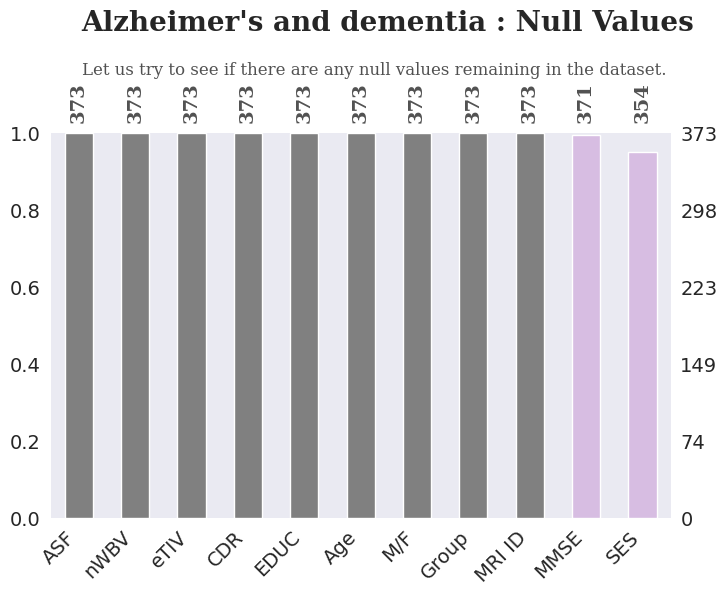

In [ ]:
sns.set_style('dark')
color = ['grey','grey','grey','grey','grey','grey','grey','grey','grey','#D7BDE2','#D7BDE2']
msno.bar(df,fontsize =14, color = color, sort = 'descending', figsize = (8,5))

plt.text(0.05,1.265,"Alzheimer's and dementia : Null Values", {'font':'serif', 'size':20, 'weight':'bold'})
plt.text(0.05,1.15,'''Let us try to see if there are any null values remaining in the dataset.''', {'font':'serif', 'size':12, 'weight':'normal'}, alpha = 0.8)
plt.xticks( rotation = 90,
                   **{'font':'serif','size':14,'weight':'bold','horizontalalignment': 'center'},alpha = 0.8)

plt.show()

# there're 2 null values in MMSE & 17 null in SES

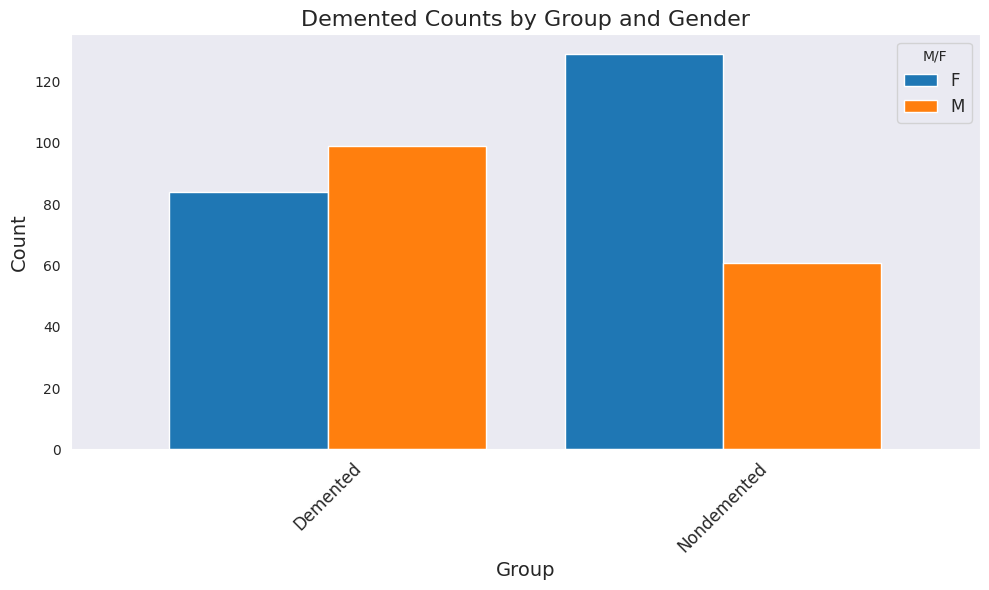

In [ ]:
# Group by 'Group' and 'Gender', then count unique 'MRI ID' values
group_rate = df.groupby(['Group', 'M/F'])['MRI ID'].nunique().reset_index()

# Rename the column for clarity
group_rate.rename(columns={'MRI ID': 'Count'}, inplace=True)

# Pivot the data
pivot_data = group_rate.pivot(index='Group', columns='M/F', values='Count').fillna(0)

# Plot the pivoted data
pivot_data.plot(kind='bar', figsize=(10, 6), width=0.8)

# Add labels and title
plt.title('Demented Counts by Group and Gender', fontsize=16)
plt.xlabel('Group', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='M/F', fontsize=12)
plt.xticks(rotation=45, fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

#The above graph indicates that men are more likely with dementia than women

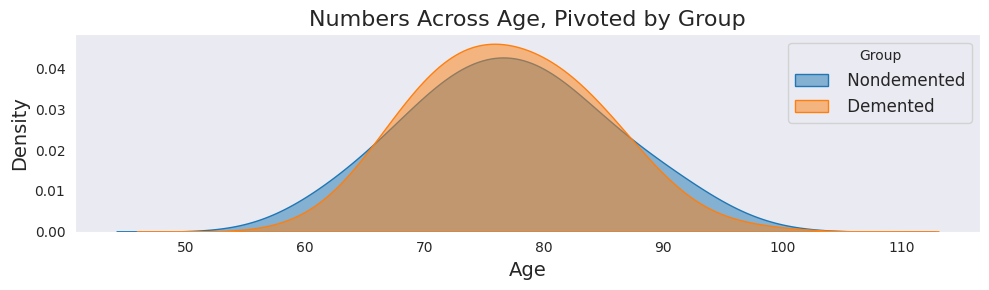

In [ ]:
# Group by 'Group' and 'Gender', then count unique 'MRI ID' values
group_rate = df.groupby(['Age', 'Group'])['MRI ID'].nunique().reset_index()

# Rename the column for clarity
group_rate.rename(columns={'MRI ID': 'Count'}, inplace=True)

# Initialize the plot
plt.figure(figsize=(10, 3))

# Loop through unique groups and plot KDE for each
for group in group_rate['Group'].unique():
    subset = group_rate[group_rate['Group'] == group]
    sns.kdeplot(
        data=subset,
        x='Age',
        weights='Count',  # Weight KDE by the MRI count
        label=f' {group}',
        fill=True,            # Optional: Fill the area under the curve
        alpha=0.5             # Transparency
    )

# Add labels and title
plt.title('Numbers Across Age, Pivoted by Group', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Group', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

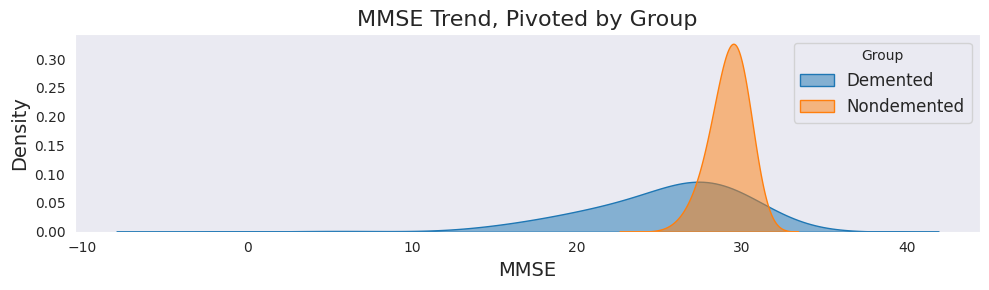

In [ ]:
# Group by 'Group' and 'Gender', then count unique 'MRI ID' values
group_rate = df.groupby(['MMSE', 'Group'])['MRI ID'].nunique().reset_index()

# Rename the column for clarity
group_rate.rename(columns={'MRI ID': 'Count'}, inplace=True)

# Initialize the plot
plt.figure(figsize=(10, 3))

# Loop through unique groups and plot KDE for each
for group in group_rate['Group'].unique():
    subset = group_rate[group_rate['Group'] == group]
    sns.kdeplot(
        data=subset,
        x='MMSE',
        weights='Count',  # Weight KDE by the MRI count
        label=f'{group}',
        fill=True,            # Optional: Fill the area under the curve
        alpha=0.5             # Transparency
    )

# Add labels and title
plt.title('MMSE Trend, Pivoted by Group', fontsize=16)
plt.xlabel('MMSE', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Group', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

#Any score of 24 or more (out of 30) indicates a normal cognition.
#Below this, scores can indicate severe (≤9 points), moderate (10–18 points) or mild (19–23 points) cognitive impairment.
# Nondenmented group presents higher MMSE and centralizes between 24 - 35

(0.6, 0.9)

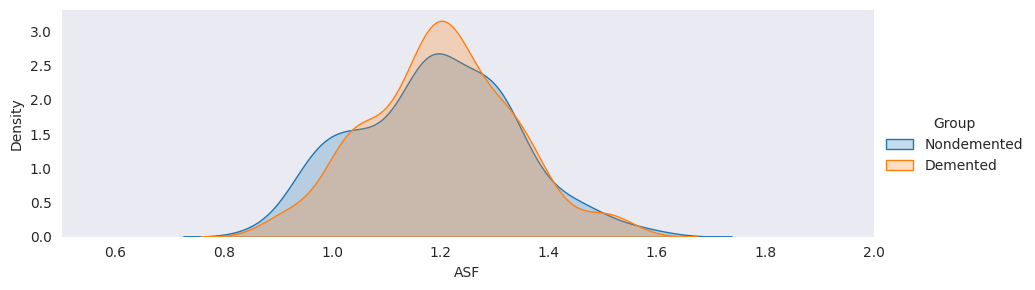

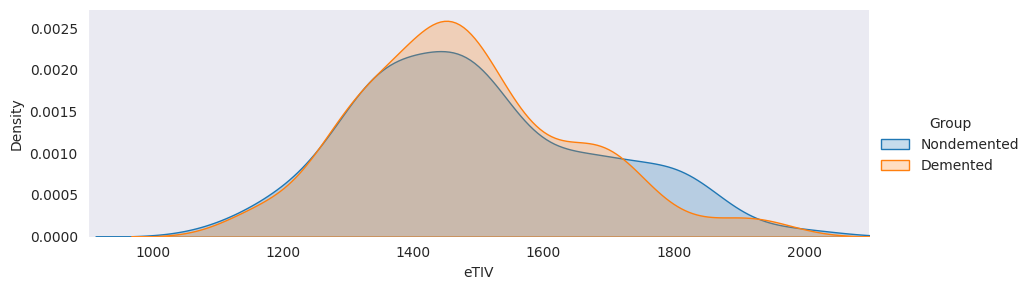

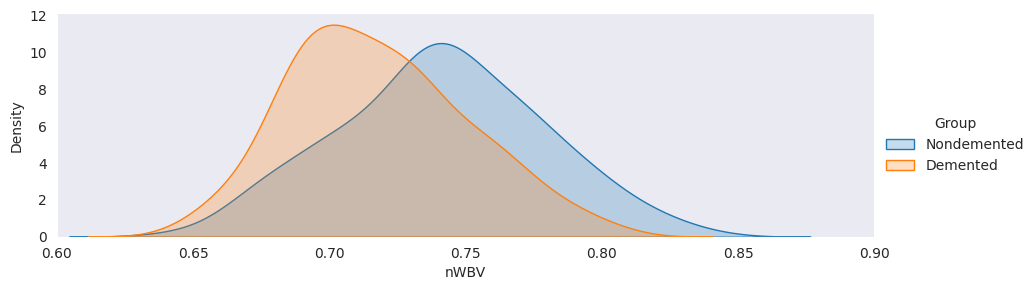

In [ ]:
#ASF: Atlas Scaling Factor
facet= sns.FacetGrid(df,hue="Group", aspect=3)
facet.map(sns.kdeplot,'ASF',shade= True)
facet.set(xlim=(0, df['ASF'].max()))
facet.add_legend()
plt.xlim(0.5, 2)

#eTIV: Estimated Total Intracranial Volume
facet= sns.FacetGrid(df,hue="Group", aspect=3)
facet.map(sns.kdeplot,'eTIV',shade= True)
facet.set(xlim=(0, df['eTIV'].max()))
facet.add_legend()
plt.xlim(900, 2100)

#'nWBV' = Normalized Whole Brain Volume
facet= sns.FacetGrid(df,hue="Group", aspect=3)
facet.map(sns.kdeplot,'nWBV',shade= True)
facet.set(xlim=(0, df['nWBV'].max()))
facet.add_legend()
plt.xlim(0.6,0.9)

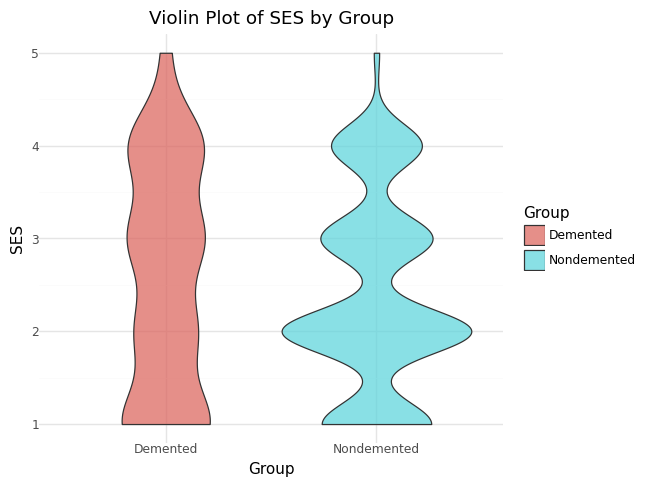

In [ ]:
from plotnine import geom_violin
from plotnine import ggplot, aes, geom_density, labs, theme_minimal

plot = (
    ggplot(df, aes(x='Group', y='SES', fill='Group')) +
    geom_violin(trim=True, alpha=0.7) +  # Set trim=False to show full density
    labs(
        title="Violin Plot of SES by Group",
        x="Group",
        y="SES"
    ) +
    theme_minimal()
)

plot.draw()
#Education codes correspond to the following levels of education:
# 1: less than high school grad., 2: high school grad., 3: some college, 4: college grad., 5: beyond college.

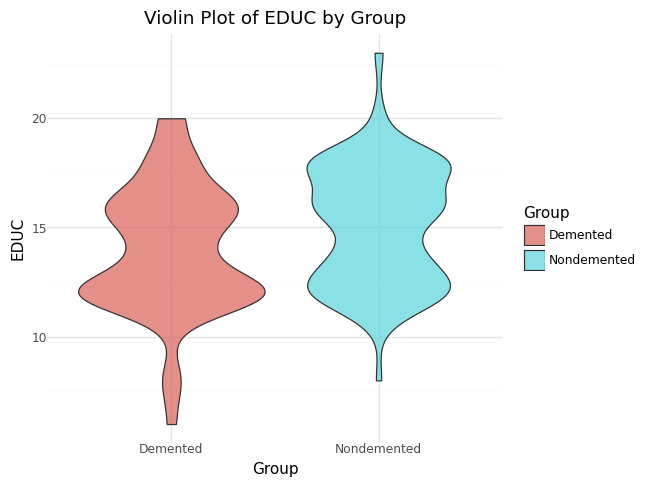

In [ ]:
plot1 = (
    ggplot(df, aes(x='Group', y='EDUC', fill='Group')) +
    geom_violin(trim=True, alpha=0.7) +  # Set trim=False to show full density
    labs(
        title="Violin Plot of EDUC by Group",
        x="Group",
        y="EDUC"
    ) +
    theme_minimal()
)

plot1.draw()
#Education (Educ): Years of Education

## General EDA Summary
Men are more likely with demented, an Alzheimer's Disease, than Women.

Demented patients were less educated in terms of years of education.

Nondemented group has higher brain volume than Demented group.

## Correlation Analysis

<Axes: >

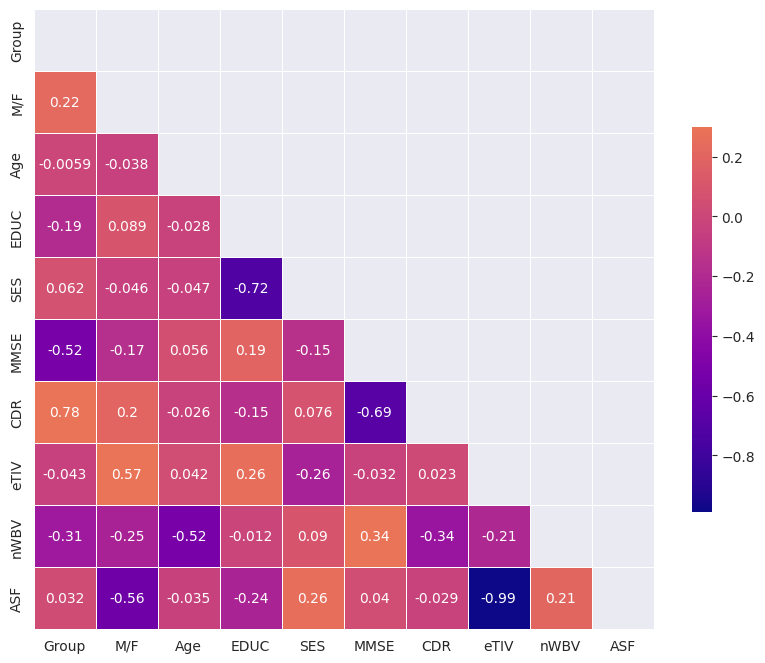

In [ ]:
# Label Encoding the categorical variables
df['M/F'] = df['M/F'].replace(['F','M'], [0,1]) # M/F column
df['Group'] = df['Group'].replace(['Demented', 'Nondemented'], [1,0]) # Target variable
df = df.drop(['MRI ID'], axis=1) # Drop unnecessary columns

# Compute the correlation matrix
corr = df.corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(10, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap='plasma', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = True)

## Prediction Model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Data Preparation
# Convert categorical M/F to numeric
label_encoder = LabelEncoder()
df['M/F_encoded'] = label_encoder.fit_transform(df['M/F'])

# Select features
X = df[['M/F_encoded', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']]
y = df['Group'].values

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Decision Tree


Decision Tree Model:
Cross-validation scores: 0.774 (+/- 0.084)

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.68      0.69        57
           1       0.68      0.69      0.68        55

    accuracy                           0.69       112
   macro avg       0.69      0.69      0.69       112
weighted avg       0.69      0.69      0.69       112


AUC-ROC Score: 0.6875598086124403


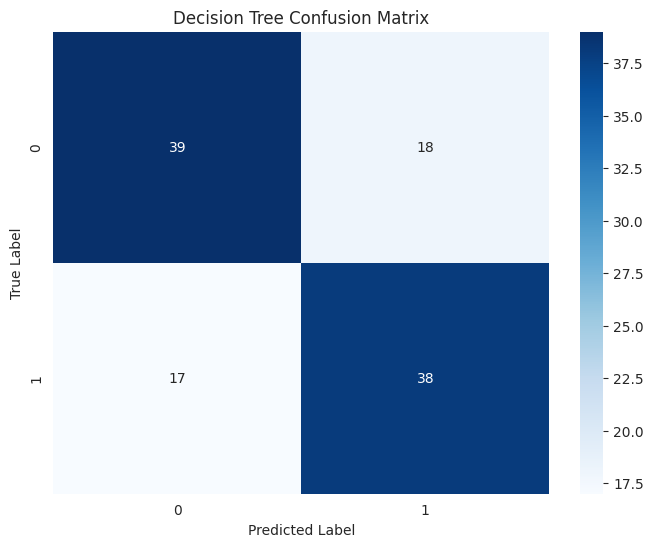

In [ ]:
# ================== Decision Tree Model ==================
print("\nDecision Tree Model:")
print("="*50)

# Create Decision Tree pipeline
dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train Decision Tree
dt_pipeline.fit(X_train, y_train)

# Cross-validation score
dt_cv_scores = cross_val_score(dt_pipeline, X_train, y_train, cv=5)

# Predictions
dt_predictions = dt_pipeline.predict(X_test)
dt_probabilities = dt_pipeline.predict_proba(X_test)

# Evaluate Decision Tree
print(f"Cross-validation scores: {dt_cv_scores.mean():.3f} (+/- {dt_cv_scores.std()*2:.3f})")
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))
print("\nAUC-ROC Score:", roc_auc_score(y_test, dt_probabilities[:, 1]))

# Plot confusion matrix for Decision Tree
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, dt_predictions),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=dt_pipeline.classes_,
            yticklabels=dt_pipeline.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

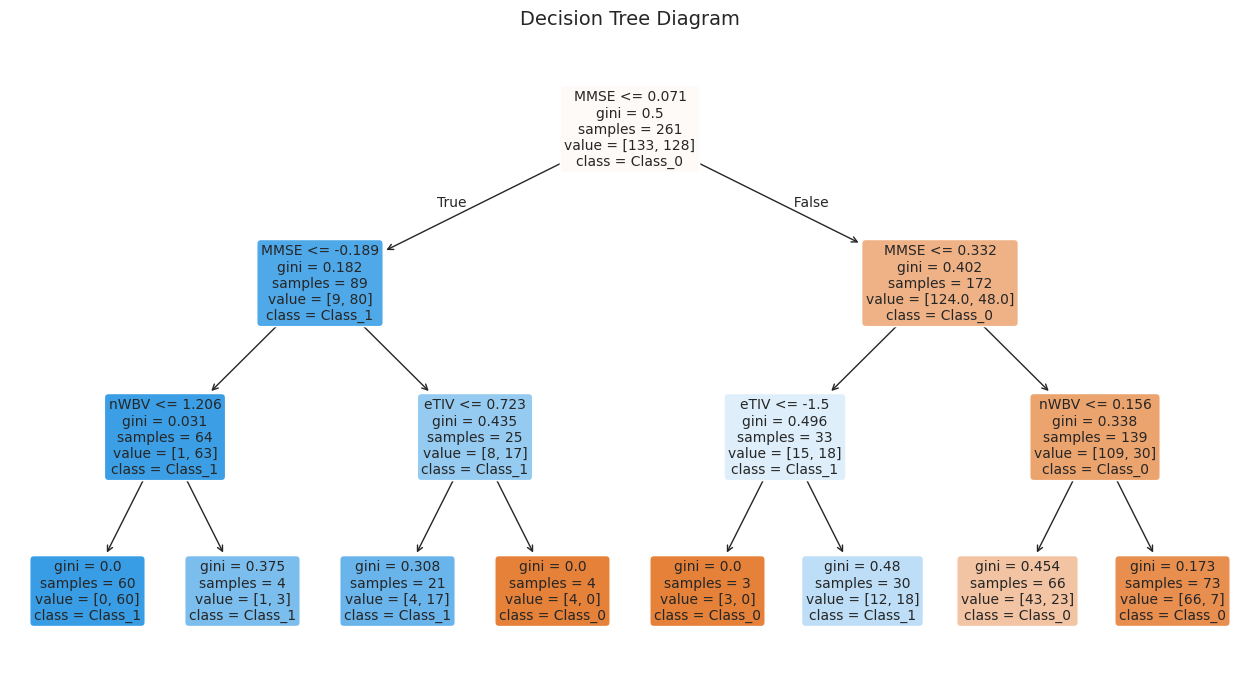

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the preprocessed training data
X_train_processed = dt_pipeline.named_steps['imputer'].transform(X_train)
X_train_processed = dt_pipeline.named_steps['scaler'].transform(X_train_processed)


# Train a simple decision tree
simple_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
simple_dt.fit(X_train_processed, y_train)

# Create the visualization
plt.figure(figsize=(16,8))
plot_tree(simple_dt,
          feature_names=X.columns,
          class_names=['Class_0', 'Class_1'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Diagram", fontsize=14, pad=20)
plt.show()

### Random Forest


Random Forest Model:
Cross-validation scores: 0.862 (+/- 0.115)

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.82      0.78        57
           1       0.79      0.69      0.74        55

    accuracy                           0.76       112
   macro avg       0.76      0.76      0.76       112
weighted avg       0.76      0.76      0.76       112


AUC-ROC Score: 0.8513556618819776


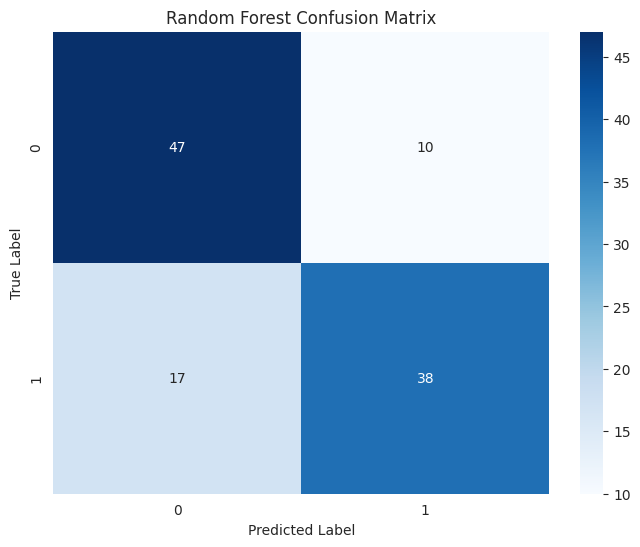

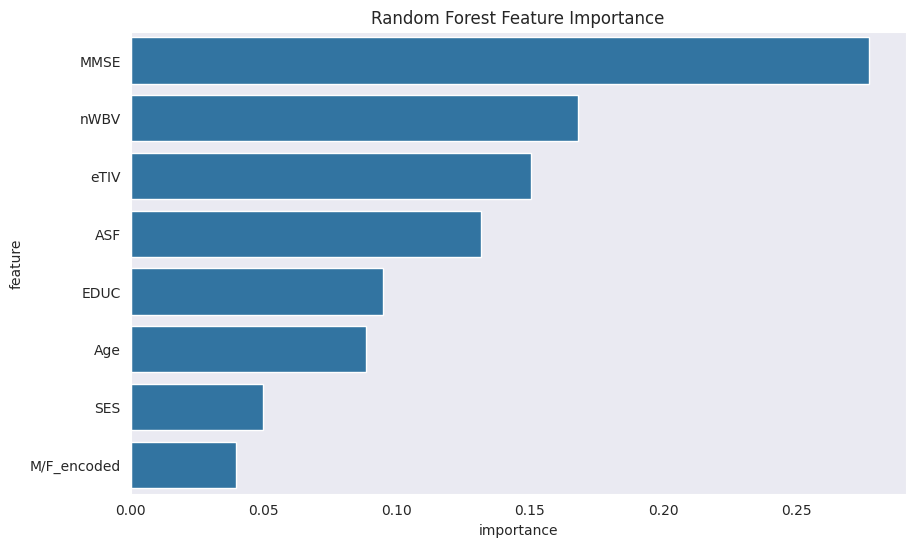


Feature Importance Rankings:
MMSE: 0.2772
nWBV: 0.1681
eTIV: 0.1504
ASF: 0.1314
EDUC: 0.0950
Age: 0.0885
SES: 0.0497
M/F_encoded: 0.0397


In [ ]:
# ================== Random Forest Model ==================
print("\nRandom Forest Model:")
print("="*50)

# Create Random Forest pipeline
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train Random Forest
rf_pipeline.fit(X_train, y_train)

# Cross-validation score
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5)

# Predictions
rf_predictions = rf_pipeline.predict(X_test)
rf_probabilities = rf_pipeline.predict_proba(X_test)

# Evaluate Random Forest
print(f"Cross-validation scores: {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std()*2:.3f})")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))
print("\nAUC-ROC Score:", roc_auc_score(y_test, rf_probabilities[:, 1]))

# Plot confusion matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_predictions),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_pipeline.classes_,
            yticklabels=rf_pipeline.classes_)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance for Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_pipeline.named_steps['classifier'].feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.show()

# Print feature importance values
print("\nFeature Importance Rankings:")
for idx, row in feature_importance.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")